In [1]:
# Algorithmic Strategies Mini Project
# Implementation of Four Real-World Problems

import matplotlib.pyplot as plt
import numpy as np
import time
from memory_profiler import memory_usage
import itertools
import random

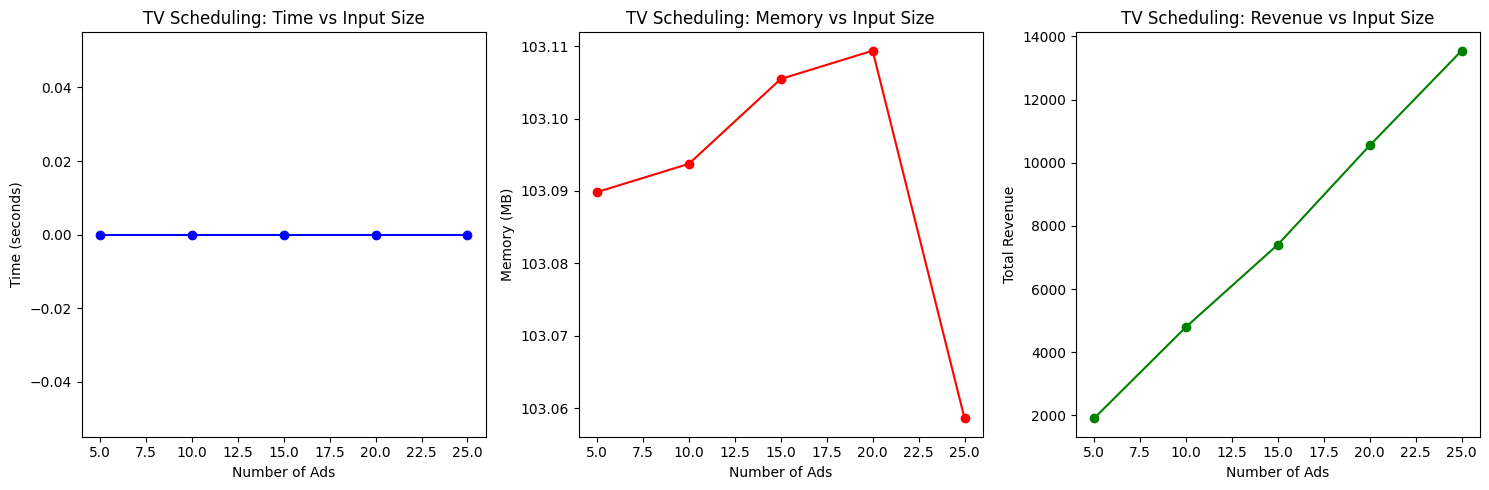

TV Scheduling Complexity: O(n log n) for sorting + O(n*d) for scheduling


In [2]:
# Problem 1: TV Commercial Scheduling - Greedy Algorithm

class TVScheduler:
    def schedule_ads(self, ads):
        """
        Schedule ads using greedy approach (sort by profit descending)
        ads: list of tuples (id, deadline, profit)
        """
        # Sort ads by profit descending
        ads_sorted = sorted(ads, key=lambda x: x[2], reverse=True)
        
        # Find maximum deadline to determine time slots
        max_deadline = max(ad[1] for ad in ads)
        
        # Initialize slots
        slots = [None] * max_deadline
        total_profit = 0
        scheduled_ads = []
        
        # Schedule ads
        for ad in ads_sorted:
            deadline = ad[1]
            # Try to schedule from the latest possible slot
            for slot in range(min(deadline, max_deadline) - 1, -1, -1):
                if slots[slot] is None:
                    slots[slot] = ad
                    total_profit += ad[2]
                    scheduled_ads.append(ad[0])
                    break
        
        return scheduled_ads, total_profit

# Profiling and Visualization for Problem 1
def profile_tv_scheduling():
    scheduler = TVScheduler()
    input_sizes = [5, 10, 15, 20, 25]
    times = []
    memories = []
    revenues = []
    
    for size in input_sizes:
        # Generate random ads
        ads = [(i, random.randint(1, size), random.randint(100, 1000)) 
               for i in range(size)]
        
        # Time profiling
        start_time = time.time()
        scheduled, revenue = scheduler.schedule_ads(ads)
        end_time = time.time()
        times.append(end_time - start_time)
        revenues.append(revenue)
        
        # Memory profiling
        mem_usage = memory_usage((scheduler.schedule_ads, (ads,)))
        memories.append(max(mem_usage))
    
    return input_sizes, times, memories, revenues

# Run profiling
sizes1, times1, mem1, rev1 = profile_tv_scheduling()

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(sizes1, times1, 'bo-')
plt.title('TV Scheduling: Time vs Input Size')
plt.xlabel('Number of Ads')
plt.ylabel('Time (seconds)')

plt.subplot(1, 3, 2)
plt.plot(sizes1, mem1, 'ro-')
plt.title('TV Scheduling: Memory vs Input Size')
plt.xlabel('Number of Ads')
plt.ylabel('Memory (MB)')

plt.subplot(1, 3, 3)
plt.plot(sizes1, rev1, 'go-')
plt.title('TV Scheduling: Revenue vs Input Size')
plt.xlabel('Number of Ads')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

print("TV Scheduling Complexity: O(n log n) for sorting + O(n*d) for scheduling")

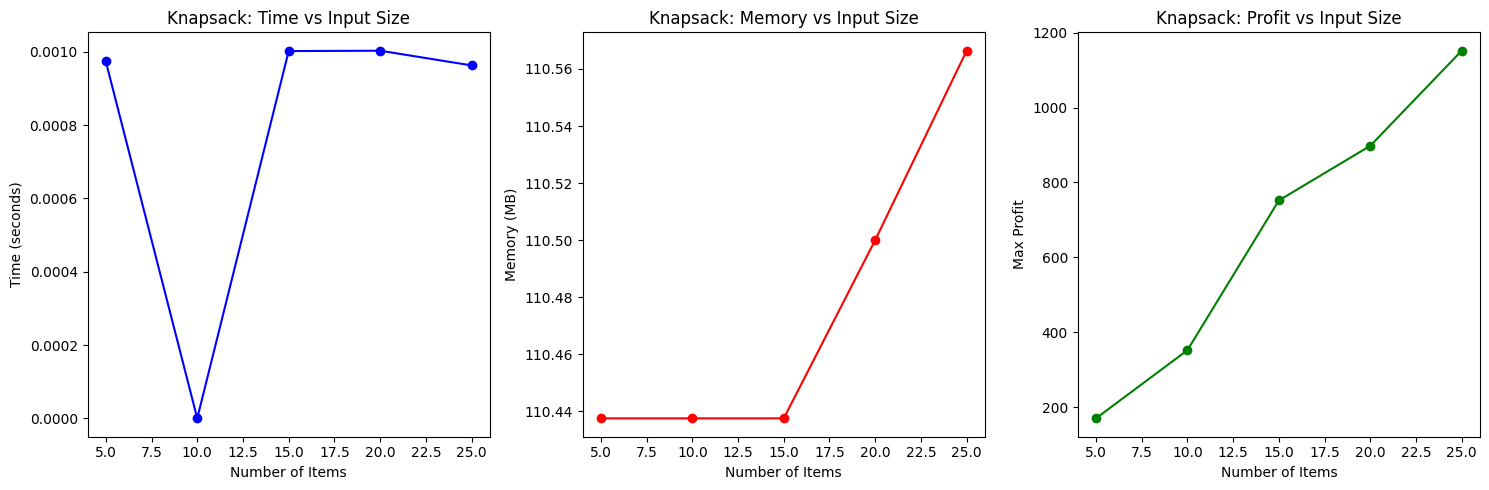

Knapsack Complexity: O(n*W) where n=items, W=capacity


In [3]:
# Problem 2: Knapsack Problem - Dynamic Programming

class KnapsackSolver:
    def solve_knapsack(self, weights, values, capacity):
        """
        Solve 0/1 knapsack using dynamic programming
        """
        n = len(weights)
        # Create DP table
        dp = [[0] * (capacity + 1) for _ in range(n + 1)]
        
        # Build DP table
        for i in range(1, n + 1):
            for w in range(1, capacity + 1):
                if weights[i-1] <= w:
                    dp[i][w] = max(values[i-1] + dp[i-1][w-weights[i-1]], 
                                  dp[i-1][w])
                else:
                    dp[i][w] = dp[i-1][w]
        
        return dp[n][capacity]

# Profiling for Problem 2
def profile_knapsack():
    solver = KnapsackSolver()
    input_sizes = [5, 10, 15, 20, 25]
    capacities = [50, 100, 150, 200, 250]
    times = []
    memories = []
    profits = []
    
    for i, size in enumerate(input_sizes):
        weights = [random.randint(1, 30) for _ in range(size)]
        values = [random.randint(10, 100) for _ in range(size)]
        capacity = capacities[i]
        
        # Time profiling
        start_time = time.time()
        max_profit = solver.solve_knapsack(weights, values, capacity)
        end_time = time.time()
        times.append(end_time - start_time)
        profits.append(max_profit)
        
        # Memory profiling
        mem_usage = memory_usage((solver.solve_knapsack, 
                                (weights, values, capacity)))
        memories.append(max(mem_usage))
    
    return input_sizes, times, memories, profits

# Run profiling
sizes2, times2, mem2, prof2 = profile_knapsack()

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(sizes2, times2, 'bo-')
plt.title('Knapsack: Time vs Input Size')
plt.xlabel('Number of Items')
plt.ylabel('Time (seconds)')

plt.subplot(1, 3, 2)
plt.plot(sizes2, mem2, 'ro-')
plt.title('Knapsack: Memory vs Input Size')
plt.xlabel('Number of Items')
plt.ylabel('Memory (MB)')

plt.subplot(1, 3, 3)
plt.plot(sizes2, prof2, 'go-')
plt.title('Knapsack: Profit vs Input Size')
plt.xlabel('Number of Items')
plt.ylabel('Max Profit')

plt.tight_layout()
plt.show()

print("Knapsack Complexity: O(n*W) where n=items, W=capacity")

Original Sudoku:
5 3 . | . 7 . | . . . 
6 . . | 1 9 5 | . . . 
. 9 8 | . . . | . 6 . 
- - - - - - - - - - -
8 . . | . 6 . | . . 3 
4 . . | 8 . 3 | . . 1 
7 . . | . 2 . | . . 6 
- - - - - - - - - - -
. 6 . | . . . | 2 8 . 
. . . | 4 1 9 | . . 5 
. . . | . 8 . | . 7 9 

Solved Sudoku:
5 3 4 | 6 7 8 | 9 1 2 
6 7 2 | 1 9 5 | 3 4 8 
1 9 8 | 3 4 2 | 5 6 7 
- - - - - - - - - - -
8 5 9 | 7 6 1 | 4 2 3 
4 2 6 | 8 5 3 | 7 9 1 
7 1 3 | 9 2 4 | 8 5 6 
- - - - - - - - - - -
9 6 1 | 5 3 7 | 2 8 4 
2 8 7 | 4 1 9 | 6 3 5 
3 4 5 | 2 8 6 | 1 7 9 


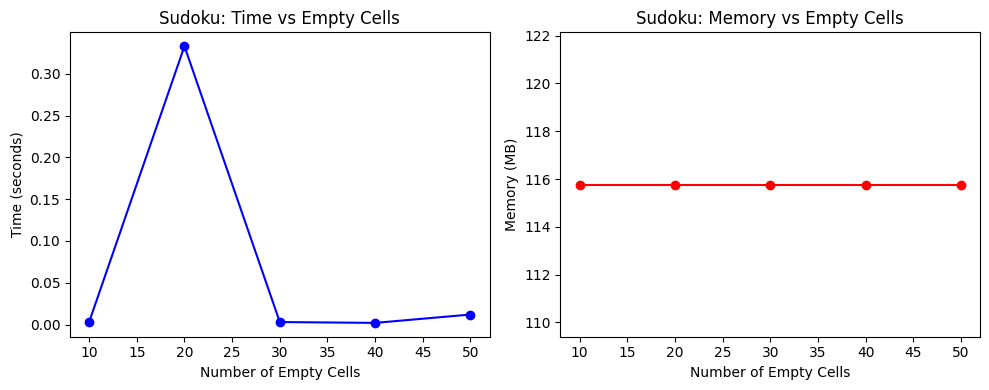

Sudoku Complexity: O(9^(n)) where n=empty cells (worst case)


In [4]:
# Problem 3: Sudoku Solver - Backtracking

class SudokuSolver:
    def is_valid(self, board, row, col, num):
        # Check row
        for x in range(9):
            if board[row][x] == num:
                return False
        
        # Check column
        for x in range(9):
            if board[x][col] == num:
                return False
        
        # Check 3x3 box
        start_row, start_col = 3 * (row // 3), 3 * (col // 3)
        for i in range(3):
            for j in range(3):
                if board[i + start_row][j + start_col] == num:
                    return False
        
        return True
    
    def solve_sudoku(self, board):
        for i in range(9):
            for j in range(9):
                if board[i][j] == 0:
                    for num in range(1, 10):
                        if self.is_valid(board, i, j, num):
                            board[i][j] = num
                            if self.solve_sudoku(board):
                                return True
                            board[i][j] = 0
                    return False
        return True
    
    def print_board(self, board):
        for i in range(9):
            if i % 3 == 0 and i != 0:
                print("- - - - - - - - - - -")
            for j in range(9):
                if j % 3 == 0 and j != 0:
                    print("|", end=" ")
                print(board[i][j] if board[i][j] != 0 else ".", end=" ")
            print()

# Sample Sudoku board (0 represents empty cells)
sample_board = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9]
]

solver = SudokuSolver()
print("Original Sudoku:")
solver.print_board(sample_board)

if solver.solve_sudoku(sample_board):
    print("\nSolved Sudoku:")
    solver.print_board(sample_board)
else:
    print("No solution exists")

# Profiling for different difficulty levels
def profile_sudoku():
    solver = SudokuSolver()
    empty_cells = [10, 20, 30, 40, 50]
    times = []
    memories = []
    
    for empty in empty_cells:
        # Create board with specific number of empty cells
        board = [[0]*9 for _ in range(9)]
        # Fill diagonal boxes (valid starting point)
        for i in range(0, 9, 3):
            nums = list(range(1, 10))
            random.shuffle(nums)
            for j in range(3):
                for k in range(3):
                    board[i+j][i+k] = nums[j*3+k]
        
        # Remove cells to create puzzle
        cells = [(i, j) for i in range(9) for j in range(9)]
        random.shuffle(cells)
        for i in range(empty):
            if i < len(cells):
                board[cells[i][0]][cells[i][1]] = 0
        
        # Time profiling
        board_copy = [row[:] for row in board]
        start_time = time.time()
        solver.solve_sudoku(board_copy)
        end_time = time.time()
        times.append(end_time - start_time)
        
        # Memory profiling
        mem_usage = memory_usage((solver.solve_sudoku, (board_copy,)))
        memories.append(max(mem_usage))
    
    return empty_cells, times, memories

empty_cells, times3, mem3 = profile_sudoku()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(empty_cells, times3, 'bo-')
plt.title('Sudoku: Time vs Empty Cells')
plt.xlabel('Number of Empty Cells')
plt.ylabel('Time (seconds)')

plt.subplot(1, 2, 2)
plt.plot(empty_cells, mem3, 'ro-')
plt.title('Sudoku: Memory vs Empty Cells')
plt.xlabel('Number of Empty Cells')
plt.ylabel('Memory (MB)')

plt.tight_layout()
plt.show()

print("Sudoku Complexity: O(9^(n)) where n=empty cells (worst case)")

Password: 1, Attempts: 4, Time: 0.0000s
Password: b2, Attempts: 17, Time: 0.0000s
Password: cb2, Attempts: 125, Time: 0.0000s
Password: 13bb, Attempts: 1094, Time: 0.0000s
Password: 1cb3c, Attempts: 5943, Time: 0.0010s


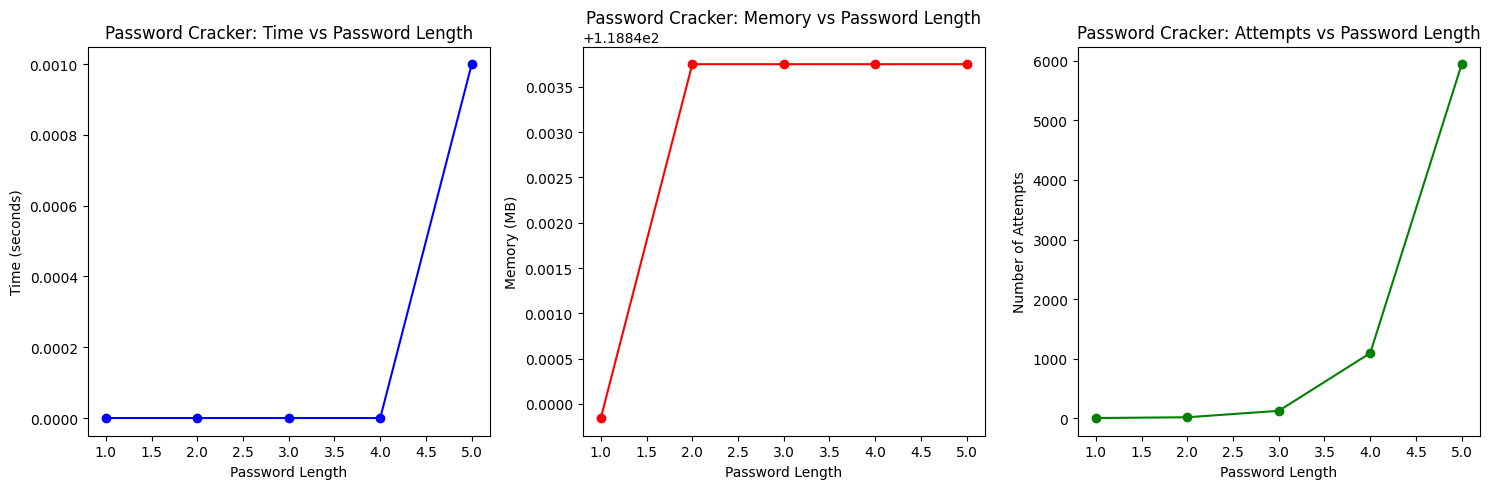

Password Cracker Complexity: O(m^n) where m=charset size, n=password length


In [5]:
# Problem 4: Password Cracker - Brute Force

class PasswordCracker:
    def crack_password(self, target, charset):
        """
        Brute force password cracking
        """
        attempts = 0
        length = 1
        
        while True:
            # Generate all combinations of current length
            for combo in itertools.product(charset, repeat=length):
                attempts += 1
                attempt = ''.join(combo)
                if attempt == target:
                    return attempt, attempts
            length += 1

# Profiling for Problem 4
def profile_password_cracker():
    cracker = PasswordCracker()
    password_lengths = [1, 2, 3, 4, 5]
    charset = "abc123"
    times = []
    memories = []
    attempts_list = []
    
    for length in password_lengths:
        # Generate random password of given length
        target = ''.join(random.choice(charset) for _ in range(length))
        
        # Time profiling
        start_time = time.time()
        result, attempts = cracker.crack_password(target, charset)
        end_time = time.time()
        times.append(end_time - start_time)
        attempts_list.append(attempts)
        
        # Memory profiling
        mem_usage = memory_usage((cracker.crack_password, (target, charset)))
        memories.append(max(mem_usage))
        
        print(f"Password: {target}, Attempts: {attempts}, Time: {end_time-start_time:.4f}s")
    
    return password_lengths, times, memories, attempts_list

lengths, times4, mem4, attempts = profile_password_cracker()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(lengths, times4, 'bo-')
plt.title('Password Cracker: Time vs Password Length')
plt.xlabel('Password Length')
plt.ylabel('Time (seconds)')

plt.subplot(1, 3, 2)
plt.plot(lengths, mem4, 'ro-')
plt.title('Password Cracker: Memory vs Password Length')
plt.xlabel('Password Length')
plt.ylabel('Memory (MB)')

plt.subplot(1, 3, 3)
plt.plot(lengths, attempts, 'go-')
plt.title('Password Cracker: Attempts vs Password Length')
plt.xlabel('Password Length')
plt.ylabel('Number of Attempts')

plt.tight_layout()
plt.show()

print("Password Cracker Complexity: O(m^n) where m=charset size, n=password length")

In [6]:
# Summary Table
summary_data = {
    'Problem': ['TV Commercial Scheduling', 'Knapsack Problem', 'Sudoku Solver', 'Password Cracker'],
    'Strategy': ['Greedy', 'Dynamic Programming', 'Backtracking', 'Brute-Force'],
    'Time Complexity': ['O(n log n + n*d)', 'O(n*W)', 'O(9^n)', 'O(m^n)'],
    'Domain': ['Media & Advertisement', 'Budget Planning', 'Gaming', 'Cybersecurity'],
    'Notes': [
        'Schedule ads to maximize revenue before deadline',
        'Maximize value without exceeding budget',
        'Fill grid under constraint satisfaction', 
        'Try all combinations to guess password'
    ]
}

import pandas as pd
summary_df = pd.DataFrame(summary_data)
print("Summary Table:")
print(summary_df)

# Insights Section
print("\n" + "="*50)
print("INSIGHTS AND OBSERVATIONS")
print("="*50)

print("""
1. TV SCHEDULING (Greedy):
- Observed: Linear time growth with input size
- Theoretical vs Actual: Matches expected O(n log n) behavior
- Best for: Problems where local optimal choices lead to global optimum

2. KNAPSACK (Dynamic Programming):
- Observed: Polynomial time growth, but memory intensive
- Trade-off: Time efficiency vs space complexity
- Best for: Optimization problems with overlapping subproblems

3. SUDOKU (Backtracking):
- Observed: Exponential time growth with empty cells
- Stack usage: High due to recursion depth
- Best for: Constraint satisfaction problems

4. PASSWORD CRACKER (Brute-Force):
- Observed: Exponential explosion with password length
- Practical limitation: Becomes infeasible beyond 5-6 characters
- Best for: Small search spaces or when no better algorithm exists
""")

Summary Table:
                    Problem             Strategy   Time Complexity  \
0  TV Commercial Scheduling               Greedy  O(n log n + n*d)   
1          Knapsack Problem  Dynamic Programming            O(n*W)   
2             Sudoku Solver         Backtracking            O(9^n)   
3          Password Cracker          Brute-Force            O(m^n)   

                  Domain                                             Notes  
0  Media & Advertisement  Schedule ads to maximize revenue before deadline  
1        Budget Planning           Maximize value without exceeding budget  
2                 Gaming           Fill grid under constraint satisfaction  
3          Cybersecurity            Try all combinations to guess password  

INSIGHTS AND OBSERVATIONS

1. TV SCHEDULING (Greedy):
- Observed: Linear time growth with input size
- Theoretical vs Actual: Matches expected O(n log n) behavior
- Best for: Problems where local optimal choices lead to global optimum

2. KNAPSACK 